In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
base = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models"
feat_path = os.path.join(base, "feat_table.xlsx")

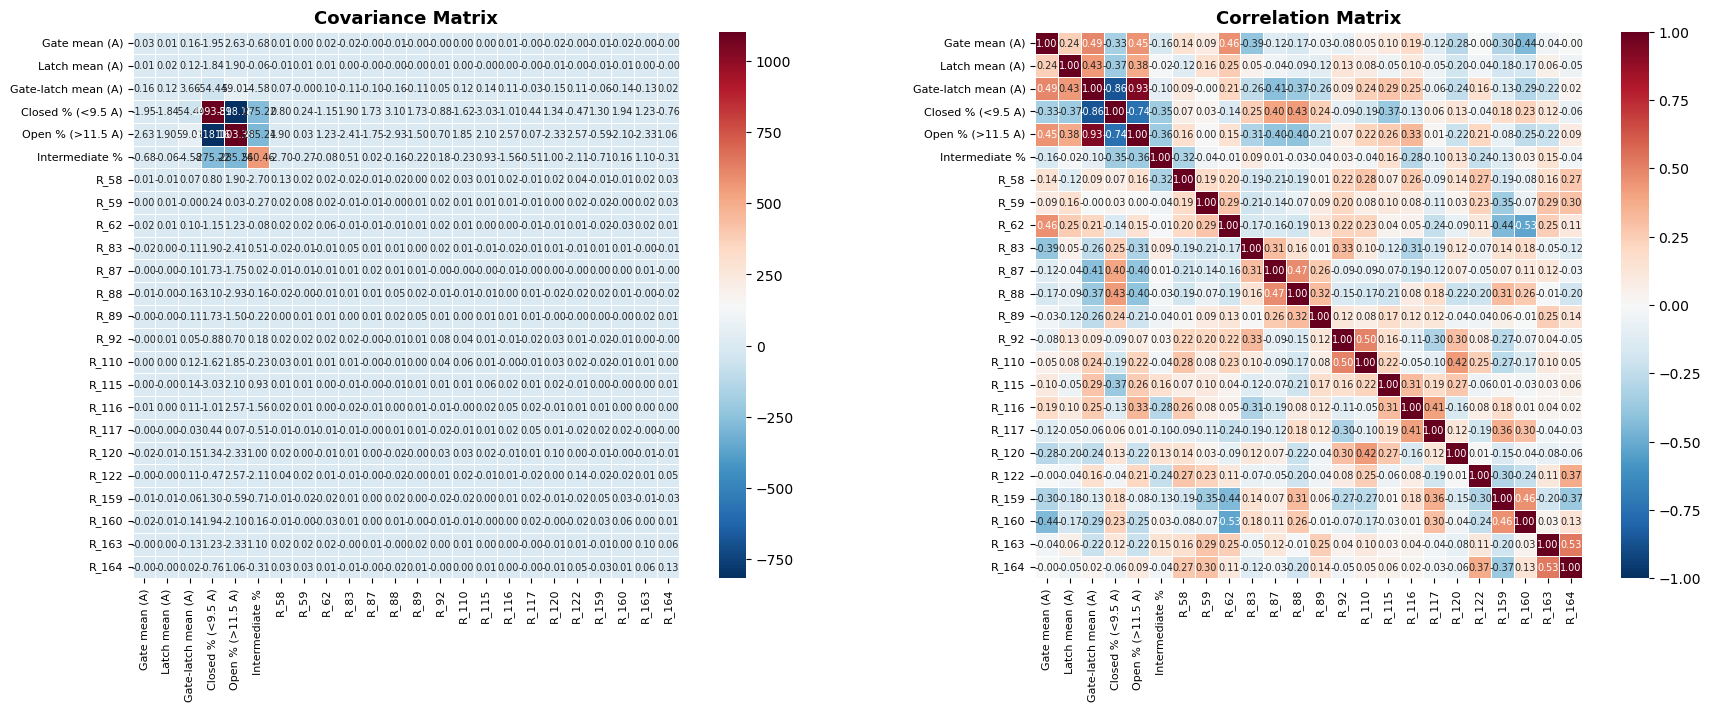

In [11]:
# --- Load features ---
df = pd.read_excel(feat_path, sheet_name='Sheet3', index_col="ID")

# Drop non-numeric / label columns if present
label_cols = ["Label", "Group", "ID"]
feature_cols = [c for c in df.columns if c not in label_cols]
X = df[feature_cols]

# --- Compute matrices ---
cov_matrix  = X.cov()           # raw covariance
corr_matrix = X.corr()          # Pearson correlation (usually preferred)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

for ax, mat, title in zip(
    axes,
    [cov_matrix, corr_matrix],
    ["Covariance Matrix", "Correlation Matrix"]
):
    vmax = 1.0 if "Corr" in title else None
    vmin = -1.0 if "Corr" in title else None
    sns.heatmap(
        mat,
        ax=ax,
        cmap="RdBu_r",
        vmin=vmin, vmax=vmax,
        annot=True, fmt=".2f",
        annot_kws={"size": 7},
        linewidths=0.4,
        square=True,
        xticklabels=True, yticklabels=True,
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.tick_params(axis="x", rotation=90, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.savefig(os.path.join(base, "analysis/ML", "feature_correlation_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()